# 1. Starbucks Capstone Challenge

### 1.1 Introduction

This data set contains simulated data that mimics customer behavior on the Starbucks rewards mobile app. Once every few days, Starbucks sends out an offer to users of the mobile app. An offer can be merely an advertisement for a drink or an actual offer such as a discount or BOGO (buy one get one free). Some users might not receive any offer during certain weeks. 

Not all users receive the same offer, and that is the challenge to solve with this data set.

Your task is to combine transaction, demographic and offer data to determine which demographic groups respond best to which offer type. This data set is a simplified version of the real Starbucks app because the underlying simulator only has one product whereas Starbucks actually sells dozens of products.

Every offer has a validity period before the offer expires. As an example, a BOGO offer might be valid for only 5 days. You'll see in the data set that informational offers have a validity period even though these ads are merely providing information about a product; for example, if an informational offer has 7 days of validity, you can assume the customer is feeling the influence of the offer for 7 days after receiving the advertisement.

You'll be given transactional data showing user purchases made on the app including the timestamp of purchase and the amount of money spent on a purchase. This transactional data also has a record for each offer that a user receives as well as a record for when a user actually views the offer. There are also records for when a user completes an offer. 

Keep in mind as well that someone using the app might make a purchase through the app without having received an offer or seen an offer.

### 1.2 Example

To give an example, a user could receive a discount offer buy 10 dollars get 2 off on Monday. The offer is valid for 10 days from receipt. If the customer accumulates at least 10 dollars in purchases during the validity period, the customer completes the offer.

However, there are a few things to watch out for in this data set. Customers do not opt into the offers that they receive; in other words, a user can receive an offer, never actually view the offer, and still complete the offer. For example, a user might receive the "buy 10 dollars get 2 dollars off offer", but the user never opens the offer during the 10 day validity period. The customer spends 15 dollars during those ten days. There will be an offer completion record in the data set; however, the customer was not influenced by the offer because the customer never viewed the offer.

### 1.3 Cleaning

This makes data cleaning especially important and tricky.

You'll also want to take into account that some demographic groups will make purchases even if they don't receive an offer. From a business perspective, if a customer is going to make a 10 dollar purchase without an offer anyway, you wouldn't want to send a buy 10 dollars get 2 dollars off offer. You'll want to try to assess what a certain demographic group will buy when not receiving any offers.

### 1.4 Final Advice

Because this is a capstone project, you are free to analyze the data any way you see fit. For example, you could build a machine learning model that predicts how much someone will spend based on demographics and offer type. Or you could build a model that predicts whether or not someone will respond to an offer. Or, you don't need to build a machine learning model at all. You could develop a set of heuristics that determine what offer you should send to each customer (i.e., 75 percent of women customers who were 35 years old responded to offer A vs 40 percent from the same demographic to offer B, so send offer A).

# 2. Data Sets

The data is contained in three files:

* portfolio.json - containing offer ids and meta data about each offer (duration, type, etc.)
* profile.json - demographic data for each customer
* transcript.json - records for transactions, offers received, offers viewed, and offers completed

Here is the schema and explanation of each variable in the files:

**portfolio.json**
* id (string) - offer id
* offer_type (string) - type of offer ie BOGO, discount, informational
* difficulty (int) - minimum required spend to complete an offer
* reward (int) - reward given for completing an offer
* duration (int) - time for offer to be open, in days
* channels (list of strings)

**profile.json**
* age (int) - age of the customer 
* became_member_on (int) - date when customer created an app account
* gender (str) - gender of the customer (note some entries contain 'O' for other rather than M or F)
* id (str) - customer id
* income (float) - customer's income

**transcript.json**
* event (str) - record description (ie transaction, offer received, offer viewed, etc.)
* person (str) - customer id
* time (int) - time in hours since start of test. The data begins at time t=0
* value - (dict of strings) - either an offer id or transaction amount depending on the record


In [1]:
from processing.clean_data import *

In [2]:
# read in the json files
portfolio = pd.read_json('data/portfolio.json', orient='records', lines=True)
profile = pd.read_json('data/profile.json', orient='records', lines=True)
transcript = pd.read_json('data/transcript.json', orient='records', lines=True)

# 3. Cleaning data
In order to do the proper analysis of the data, the three datasets need to be cleaned first. The portfolio and profile datasets will require less work, while the transcript dataset (which includes offers and transactions that may or may not be connected to offers) will be a bit trickier due to how the data is originally structured. Let me start first with the easier tasks.

## 3.1. cleaning the portfolio dataframe

In [3]:
portfolio

,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"[web, email, mobile, social]",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"[web, email, mobile, social]",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"[email, mobile, social]",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"[web, email, mobile, social]",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"[web, email, mobile]",10,7,discount,2906b810c7d4411798c6938adc9daaa5


In [4]:
portfolio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reward      10 non-null     int64 
 1   channels    10 non-null     object
 2   difficulty  10 non-null     int64 
 3   duration    10 non-null     int64 
 4   offer_type  10 non-null     object
 5   id          10 non-null     object
dtypes: int64(3), object(3)
memory usage: 608.0+ bytes


There are a few things that need to be taken care of:
1. `channels` column contains lists of marketing channels. There is a way to automatically split them into separate columns with binary (0/1) values for the benchmark model. Alternatively, since LightGBM will be used as the main model, unique channel lists can be turned into integers, and I can let LightGBM handle such a categorical variable through its internal algorithm.
2. `offer_type` is a column with string one-word descriptions of the type of the offer. Those can also be one-hot encoded (for the benchmark model), or turned into integers for LightGBM to handle automatically as a categorical variable.
3. `duration` column consists of integers which represent the number of days, however when we'll later look at the transcript dataframe, timesteps are hours, so it would be good to add a column that gives duration in hours to avoid later problems while processing the data.

In [5]:
portfolio_clean = clean_portfolio(portfolio)
portfolio_clean

,reward,channels,difficulty,duration,offer_type,id,email,mobile,social,web,bogo,discount,informational,channels_int,offer_type_int,duration_h
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd,1,1,1,0,1,0,0,0,0,168
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1,1,0,0,3,0,120
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed,1,1,0,1,0,0,1,2,2,96
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,0,1,1,0,0,2,0,168
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,0,0,1,0,1,0,1,1,240
5,3,"[web, email, mobile, social]",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,1,1,1,1,0,1,0,3,1,168
6,2,"[web, email, mobile, social]",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4,1,1,1,1,0,1,0,3,1,240
7,0,"[email, mobile, social]",0,3,informational,5a8bc65990b245e5a138643cd4eb9837,1,1,1,0,0,0,1,0,2,72
8,5,"[web, email, mobile, social]",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d,1,1,1,1,1,0,0,3,0,120
9,2,"[web, email, mobile]",10,7,discount,2906b810c7d4411798c6938adc9daaa5,1,1,0,1,0,1,0,2,1,168


## 3.2. Profile cleaning

Let's do the same with profile data.

In [6]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               17000 non-null  int64  
 2   id                17000 non-null  object 
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 664.2+ KB


In [7]:
profile.head()

,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


It seems that there are several important problems that need to be dealt with:
1. there are missing `gender` and `income` values
2. `age` values for rows with missing values in other columns seems to be 118 at first glance - it is not a realistic value to have so many customers of that age
3. `gender` needs to be turned into a binary column
4. further preprocessing of `became_member_on` is also advisable; it seems to be a column filled with dates

In [8]:
profile_clean = clean_profile(profile)
profile_clean.head()

,gender,age,id,became_member_on,income,year
0,0,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0,2017
1,0,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0,2017
2,1,68,e2127556f4f64592b11af22de27a7932,20180426,70000.0,2018
3,1,65,389bc3fa690240e798340f5a15918d5c,20180209,53000.0,2018
4,1,58,2eeac8d8feae4a8cad5a6af0499a211d,20171111,51000.0,2017


## 3.3. Transcript cleaning

The main difficulty while processing the data will be related to the transactional/offer dataset. Let's have a look at some rows of it.

In [9]:
display(transcript.head(20))
display(transcript.tail(20))
print(transcript['event'].value_counts())
pd.Series([list(x.keys())[0] for x in transcript['value']]).value_counts()

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
5,389bc3fa690240e798340f5a15918d5c,offer received,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},0
6,c4863c7985cf408faee930f111475da3,offer received,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},0
7,2eeac8d8feae4a8cad5a6af0499a211d,offer received,{'offer id': '3f207df678b143eea3cee63160fa8bed'},0
8,aa4862eba776480b8bb9c68455b8c2e1,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
9,31dda685af34476cad5bc968bdb01c53,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0


,person,event,value,time
306514,f1e4fd36e5a0446f83861308bddf6945,transaction,{'amount': 8.2},714
306515,0b64be3b241c4407a5c9a71781173829,transaction,{'amount': 2.6},714
306516,86d03d35d7e0434b935e7743e83be3a0,transaction,{'amount': 9.2},714
306517,3408fd05c781401f8442fb6dbaaea9c7,transaction,{'amount': 11.7},714
306518,1593d617fac246ef8e50dbb0ffd77f5f,transaction,{'amount': 40.67},714
306519,f1b31d07b5d84f69a2d5f1d07843989e,transaction,{'amount': 31.13},714
306520,2ce987015ec0404a97ba333e8e814090,transaction,{'amount': 1.6400000000000001},714
306521,2e33545f0a764d27b2ccff95fc8d72c4,transaction,{'amount': 17.35},714
306522,d1c4500ace2e45e9a45d3cd2fccac8d8,transaction,{'amount': 4.42},714
306523,b65affd9e07346a1906364a396950e3d,transaction,{'amount': 18.35},714


transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: event, dtype: int64


amount      138953
offer id    134002
offer_id     33579
dtype: int64

There are several major problems related to the transcript dataframe.

1. offer events and transaction events are mixed together. In order to be able to get the right dataset to assess the impact of an offer on the spending amount, the transcript dataframe needs to be heavily transformed, and the transformations required seem to be non-trivial.

2. A smaller but still important problem is the fact that the `value` column contains different keys that have to be separated. The <i> amount </i> key is related to transactions. Then, <i> offer id </i> and <i> offer_id </i> keys have to be concatenated to make later transformations easier.

While the preparation of the final dataset is a major task that might require multiple functions, let's first clean the `transcript` dataframe's `value` column.

In [10]:
transcript_clean = clean_transcript(transcript)
transcript_clean.head()

,person,event,time,amount,offer_id,reward
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN


Then I need to think about how the transcript should be transformed to have the proper structure for analysis. The main goal is to have a dataset where:

1. Each row contains data about what happens with each offer during its validity period
    - some offers will be viewed but not completed; customers might still be aware of the offer and make purchases even if it does not mean that the offer will be completed
    - some offers will never be viewed, which means the customers were not influenced in their transactions and are not aware of the offer at all (unless they accidentally complete it)
2. Attributing a transaction to an offer means that the offer must have been viewed; any transactions that happened before viewing will not be attributed to the offer
3. There might be some overlap. Certain transactions might have happened when the customer was aware of more than one offer. These transactions should not be counted in any aggregation; rows concerning such overlapping offers should also be removed from the analysis that deals with assessing the impact of a <b> single </b> offer.
4. For the sake of the analysis, the impact of a viewed offer ends when the offer is completed and/or the offer expires (n days from receipt, depending on the offer)


The dataset cannot be easily transformed with one-liner pandas transformations. To the contrary, the transformations need to be iterative and a completely new dataframe needs to be created from them.

Let us think of an algorithm (written in pseudo code)

<b> for </b> each customer <br>
&nbsp;&nbsp;&nbsp;&nbsp; <b> for </b> each received offer <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; check if and when the offer was viewed <b>(must happen before completion/end) </b><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; check if the offer overlapped with any other viewed offer <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; if offer was viewed and there is no overlap, calculate the sum of transactions that happened between the viewing of the offer and its end/completion<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; calculate the sum of transactions that happened when the customer was not yet aware of the offer<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; calculate timeranges for both the offer running and when it was still not running (viewed)<br>
&nbsp;&nbsp;&nbsp;&nbsp; <b> for </b> timeranges without any <b> viewed </b> offer running <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; calculate total money spent <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; calculate total duration without an offer

The result of the above algorithm's implementation should be a dataframe that can then be joined with profile and portfolio datasets. This dataframe will allow us to get the <b> hourly </b> transaction sum for a given customer, dependent on the offer or the lack of it.

The reason why the hourly rate is used can be explained with an example:
- a customer spends 20 dollars without a runnning offer across 265 hours
- the same customer spends 10 dollars when an offer was running (across 20 hours)
While in general the customer spent more without a running offer, his hourly spend was much lower. If we just took absolute spend values, it would give the wrong impression about the importance of a specific offer.

In [11]:
qry = '''
    select distinct
        r.*, v.time as time_viewed, c.time as time_completed
    from
        received r
        left join viewed v on r.time <= v.time and r.person = v.person and r.offer_id = v.offer_id
        left join completed c on r.time <= c.time and r.person = c.person and r.offer_id = c.offer_id
    '''

In [12]:
df_offer_final, df_transaction_final = create_final_offer_and_trans_dataset(transcript_clean, portfolio_clean, qry)

In [13]:
name = 'data/finaldata'
my_file = Path(name + ".csv")
if not my_file.is_file():
    final_df = get_dataset(df_offer_final, df_transaction_final, portfolio_clean, profile_clean, name, True)
else:
    final_df = pd.read_csv(name + ".csv")

0009655768c64bdeb2e877511632db8f
00116118485d4dfda04fdbaba9a87b5c
0011e0d4e6b944f998e987f904e8c1e5
0020c2b971eb4e9188eac86d93036a77
0020ccbbb6d84e358d3414a3ff76cffd
003d66b6608740288d6cc97a6903f4f0
00426fe3ffde4c6b9cb9ad6d077a13ea
004b041fbfe44859945daa2c7f79ee64
004c5799adbf42868b9cff0396190900
005500a7188546ff8a767329a2f7c76a
0056df74b63b4298809f0b375a304cf4
0063def0f9c14bc4805322a488839b32
0069a50874d846438e58acff5e594725
00715b6e55c3431cb56ff7307eb19675
0082fd87c18f45f2be70dbcbb0fb8aad
00840a2ca5d2408e982d56544dc14ffd
00857b24b13f4fe0ad17b605f00357f5
008d7088107b468893889da0ede0df5c
0091d2b6a5ea4defaa8393e4e816db60
0092a132ead946ceb30d11a1ed513d20
0099bf30e4cb4265875266eb3eb25eab
009d10c2c38a4fd795a7bc6ddbbddb78
00a794f62b9a48beb58f8f6c02c2f1a6
00ad4c2cace94f67a6354ec90d6c6f45
00ae03011f9f49b8a4b3e6d416678b0b
00aee28bbb3848dd8a31f0c91dc267dd
00b18b535d6d4f779dea4dc9ac451478
00b3400e4ff64ee68ce9ada1d0c222f0
00b3c376db2a4115af3aef34a02f61d6
00b5fb9d842d437e83033ad9e36f7148
00b901d68f

03e866224ec641c58bc93a69be00de9c
03ef53e2d3e1436eb3b2042a4825adec
03f1ad04292f47b2b1299cc92f8f2a5d
03f75ac6db7a457dbd6086e6b86a4fd1
03fbbeecf81b468684b50dbe63ac4587
03fe8e9f855846c88fd01c4b7b147db7
03ff3cf4aec84162be697c28346bdd5a
040704e99ab84cd08977858fab9b9276
0409252539634eca8a8d1b5407caa582
0409df7f3af74e8c813d975fbd4ceb02
040b2e6d3e914d609f6764b34b5a3a88
0414fcebbd7f4a19bca352622b1c84e2
04189492f0aa46f2b6fefe34ffbc7062
041967ceb80841ddbd306958d4f744ac
041f00ddd6f340b18c174a0c997c9955
041fd7c6b796430a867c4e03d2ff8f4d
042d7ab61d1143fe9230bcb1af34aa5a
04326bc8a2e94fe09557d30388647e52
04362cece3104f4ebcb3d49ef0bc7e9c
04369aa7ac9a4440a794c471ae7c3f77
043702ae29bc426e9f65ef7beb6cd08a
043b6b6be98c412d901f7f376e0548d0
043bcfeacb874bbc837300701ce25870
04452c214f5f401bb1418313c1526cbb
044a7e5bbe7f4c66a898ad1dc4bc0049
044f41cfd98940119477d73c81f973a3
0454292436bd4cee98e8ec873e30433e
0456cf6870f849cc9e1ac5ea9e02dccd
04698a1182a24807ad4c36f12b67c5ef
046a2f9c32c14e7e9ad508f811ebfa2e
0471fe9484

07d8e818a7d34429aae9d19958913a58
07dc543bf5d24eb9893c1a3f199f275f
07df8065f7894333b51f57c1999dfb6c
07e29d02d0074da28b430e1dc40cc1fc
07e7d74b98e9496eae8226d4af05f33b
07ebe89c877e4328b60f4e5676452ee1
07f1d6d949634863bb93b0e9fd0dc8f0
07f4ec4a70cd456583e224bb6d2d1787
08031f6005104429b664b7abd3a54136
08081f80dad246c29d7ef266ff3f4765
08083d179b0b4c1e895c27261aca17a7
0809ff2ff8fe461ea8996377a7abd46d
080ee808af4d416ab7c598b3bf2855ba
080fc5e11b2a4dbeb88e1ffa952cb638
0821c517c4544631b2f540933caeb98b
08243bf7c8df469591c0b9d29074463d
082624ed9a14484e914323d0cd586ca8
083145b8b0004b21bd4433134747c6b2
08331c061bd140c2ae27b8d735763e79
08377118255f4374b173879fa81b8100
083977ebbd00410dbc2054e7fd62513b
083d316ee57640689731e5e7be9d5c20
0842bae0ce7f4dd283c868b01a19f793
0844b119bdc542cdb54188f4f10b7eb1
0846873e9e4d4d19afa993278b1e8f3d
084afe9e774d4e54b5ccaf786cd29f67
084c6cf4cd3a46a288e55ab2213e644c
0854b236fc3b422d88cee4cb6d44ce0c
08579355f46b49efa8412ddacc4ac832
085efb39e80140f08b90e0d77299958b
0860d25635

0b73997a269247088b2a63355f53ee58
0b7b452e6b9042839d3d6d15c057d23e
0b83ad12131140a9bd1b2e5e1ae457e4
0b8503be108149b58bdd5f1827612fdc
0b854279718f4295a7a6bae7cd7ee2e3
0b8684abe074418d9ec08eee090f1859
0b86e2ad1f2140db8dc4db1b71e1e73a
0b9248aa06a24ff991321150b8b56098
0b931f3c0c9049dd825fc371e4d759f9
0b99a9ca8c8946cda19fe7b27df89a2b
0b99c75c3e0e424fafe2975a64d66e00
0b9c42f29edd4e0cbbcdc22ebdeb937c
0b9cac742f534951b5af48395dfe6879
0b9d749dd7c4461c8b4547eea2ddaa65
0ba0d7ac80a94d28b831018681656c8d
0ba55f2ffeef4c70b34e1838ee36f920
0ba5ddd198e04ce3837c1ee2fbb3e4b1
0ba6584a372247e68f0ddcbf98316a0a
0ba6e2ad781c4429afd26cf0b35f2d11
0ba8b605e9ab4114b55d26c267fdff7f
0bab4b4713984db0ac68a9a42f6af163
0bb1b63ae72141ceaa722b966df2d6d2
0bb2879db8a0458fa7cb17280a54847f
0bb50a84fe1040c69f941f6f34f751b2
0bb56cebce3342c0a71fd5aca70abab2
0bbcf0985bd04fc4bbf77b4500ada512
0bc0a681c7a74a4abd36563d3f3646b2
0bc7c49f736c4a7fb104595df8c54d74
0bcecfedf7e448b08e5ed4c00f47217d
0bd0abaa6fca42d8b186c24c78358fa6
0bdd63f533

0f45882b7ebf44be98626ba118e034a4
0f46a272dd8b4b789e31f910653fc8f4
0f4a68826e204f45be2a1103dcc5b014
0f4a7a715cfc440796175a7c5afb168f
0f4ea68d60614ce2a683c039425f160c
0f4eeccda01547bdaa30113a09725a2b
0f514f07701a4ae99075ba8826c9ba44
0f54094029ca4107bfd36203aeb3ed14
0f5cb923d0a74415aca9ce5dd0c60e46
0f5cd14cf15242bfabac7836af6b1653
0f5f04b19ad149eab00dca33360fb8e2
0f628df0d3fb4e1192f156de98ec4a0b
0f637145a20445b1bfb484df49062340
0f6496ef526940d3a2e091ed2a3056d7
0f6b76564fbb446c977f5330b3d8567c
0f6cf9619c4341e89a099e951300a2ea
0f6d41cb9bd144e3b091286856d12f5c
0f6ff347c72c45ecb8a10010061419cb
0f7594c807334a22a181ffe7a0e6f1b9
0f792a0ea8cb4a6c86cf52c055f1510f
0f805acee74a41569d7a467285231bf0
0f876bcb1d2f48b9bb905d31e72ea01c
0f89bd1fee15490dab326aa5ea95eccc
0f947d450cb4409b8084bb342cfc895e
0f9b11a3bcde4537aab7f8560460096d
0fa15afeba8742808fac651d0611a018
0fa86ae026dc4ed3a9ec0f4676239e9d
0fa904f04da74ef5bd2bd52cd22fc792
0fa9cb0814914f778995e061d4460e1a
0faa918444744117808623014e14ce7e
0fb53c5429

...

f092d429217c4a18a2c326971bbc4b7e
f093e47717a7481786d016b1fe56d1ad
f0948561f6c14c279acfc703234baeef
f094fae8936e4c38b5bef23428f71961
f0954d1f55444d6aba231d732be8ebdc
f0986f270b1f4112bc3254366325f819
f09de4c8c9a04232ae23b203cdfecc47
f0a08a63363940a8bf6124a7cca1683b
f0a3a3c05e3c4e2e84929a49a6b5488c
f0a5f53e6d664fdbbd9ade454d40f0d4
f0aba2cbde6042bf8b46ed5478aa724b
f0b38ab2fd2b4a88a4a56c8236ed02d2
f0b93802ded54d7f8695e27ed4009a42
f0bc9582fc5e4bf5bf26532fc8fb0f0b
f0c40762405c4b87bbb244c5b90001ed
f0c6122617704fe1a1b669f380266635
f0c6c6a4fd6e485ca767ac21a78fb4af
f0c7c3967f634607b09e9559b3427427
f0c8862f53e9488fabaa3d1b44352b18
f0ceb17311614d6fb67eeeefe1011b01
f0cfff24201745f79321abb1101ebef2
f0d129d6bb79456b8529884a83d16007
f0e126082e4940749c3087f8016106a0
f0ea4ff9485045ffb647a09f3b9c3063
f0eafd499d9c42a991e89d34a0eec489
f0ec5023e1d1406dbcadf99a5397126d
f0ef4f6d585941e6a7f15e9c70772b38
f0ef63b28f2540fe811b8d9935ec61f5
f0f0fa6309b84e8ba862bf241eb620dd
f0f10e521acb43febb2049132cda64e1
f0f5734f7a

f47de7e07e1149429d604937326ae500
f4809b14614f4420b2f9a4dc0d5a0a3e
f488a534b7204529908f1f95a6bd92cd
f490559d2e3d45be94bd05cbe025c721
f490e04e9dbd4bb186712a61b0ef41bc
f49468382d5a42629dfc8ec2a9eb969f
f496c159664c42dca6fff0c428ef5973
f4993aab5e10447ab712adadf3829e68
f4994572197d4310bf922576d5a8d132
f4996c5638134185b27f27e8bb0adaf1
f49e624a9f79456ab29e3c19f4b8e8cf
f49ea4a7ff694967a8716c8d85d7e394
f49f313a4a434c1fa4cfec2a78416f5b
f4a11bc75a014ad9996a79170fb59ec9
f4a13092c08f41b1a6f9f47abfe6fa5f
f4abc57c62044d5f9fa264af91930b5d
f4b22893fbf54becad1039fd562ca089
f4ba292455304d21857a621076ac9f99
f4bc91d5a549410d8f98a2461dc24baa
f4c32bae2bb14c9aa6dc48625a6ad758
f4c75d8d43054e86993529f63ca54f00
f4cb104e224e44378c49879473db2891
f4cc683bfa304902beea71f5353420a2
f4d2cc6759ff4ada82765afea30d8662
f4dfef33b50444eeafce52a81e862f0b
f4e0715b897c480e9cb7b72cec1a8607
f4e159dd12ac41779c2fd8ba3b68dcdb
f4e2258e9c23436e8db7dea8a2e12ec5
f4e953ec3a484683935d8d42216fd11e
f4ef9a434c22420b8d7528602f777375
f4f6298b02

f883a0574d944b0488bca8cc4b22a728
f8890c7bddcb4aa791b04ca8ec023b0d
f88b5bd46f854ea19c8ffaf9b2543511
f88e91a11d8f405b9a47ad3741415b83
f891cadf773f4be896c7b65589491ad2
f8961e32857d4f2f97183ef480da2ab9
f89a821a9dd240fbbf05c17f24452ae8
f89ae66e3f37435099b1fb443c937664
f89b838f0225472fa5d191e25778f8e4
f89cde99c9bf4182a371dd808a0ad2f1
f89e6073e064425fa74beae2e093dc48
f8a0d2e3a8464ce3929391a5f2b2ddb2
f8a59176e4a84d2786e0ebb892fb322f
f8a65501eb514811872b5438a75d618b
f8aedd0cbea0419c806842b4265b82e5
f8c07073fb89432d996725a3225e5e38
f8c45b7197e2414dac38c6f36f4d492f
f8d253b227e74e9b82ef382d31b3b7d2
f8d279c6b0df4fdda22c3d85ecc32a9e
f8d47095f4a5472abc9065b7ec74fbc7
f8d4fae1b4384aa98094a5dc625eaa43
f8d52526c7714472ba97f3e87931bebf
f8d5bbfd39f541888eddc357a8e4e6e2
f8d61365a8064816917c950076174ef0
f8ddf5ee3d1547cb923ca77addb32784
f8e1667028a44d4b969a55774352235d
f8e1a46daab849268feecf21ba67ae50
f8e3fa27b11042acb311795da7e4ff56
f8e69750104947f0a16bfed5dab877ce
f8e6f303728449f0a610f7fce625d1da
f8ed60edd1

fbf945cf7c8d443ca2bbef68fdf3b248
fbfd90953e754794ac3323c43881992d
fbfe4e14cb5147d2b0ce619378b40069
fc05227412c64551b11d24e6a07332c1
fc0561465fd34eb0a59bc1a7995285f6
fc05bce7d72a41fba357e26b7ef2d70a
fc0fc865ff004b778464fbcc36fb0fc6
fc12f97780a245f39af4f3516224edd1
fc2080bf9ecd4463bbec680953e4cfcf
fc2228d148ad45b2a4043425dd23f187
fc2b076b67954763a290437d6ca1160a
fc2cf70b22fe494d9c7be20329b9754e
fc3405b8b39d40cb81af12db2c9064c3
fc3444ae44044a218e160522f7de8d8d
fc3d0f06f8f04765b9f8e148bac39c0e
fc41f98eaccc4c6e9ba3d3361714c527
fc461f072d524298a4bba5550841e92b
fc4b89cd1c074eb29a3d26c319eb60ae
fc4be034b72a42e999e54c40cdb80dc5
fc4bf7eecf2a438c925f2c3cb43355d3
fc505c0e65564765a6c65396619b444f
fc543a5400c742f39aff9b7d654227e4
fc546aaa32694c5cadfc43b97b563434
fc58860830e648c9b54785967b67434c
fc5c03ed88994b60bff2839cc428c313
fc5ec01a59cd4cb483837f44329bcefb
fc69570a2ba74e92b1bf03cc30b1c66a
fc6da58cb232469b8edfca9b688f8343
fc6f8cad47564c499ba674fcf9f525d3
fc70e24adcad4a61962e04e851363a3d
fc73a0a1bd

ffdefcac307f4ca99ac1ebd51470f106
ffe5257abf8840b395e1ee6b29894637
ffeaa02452ef451082a0361c3ca62ef5
ffecb1f8543f4bf7bade023de366d6bf
ffed75d3abc64b488982f50ed12878b5
ffede3b700ac41d6a266fa1ba74b4f16
fff0f0aac6c547b9b263080f09a5586a
fff29fb549084123bd046dbc5ceb4faa
fff3ba4757bd42088c044ca26d73817a
fff7576017104bcc8677a8d63322b5e1
fff8957ea8b240a6b5e634b6ee8eafcf
fffad4f4828548d1b5583907f2e9906b
ffff82501cea40309d5fdd7edcca4a07


In [14]:
final_df.head()

,person,offer_id,reward,difficulty,email,mobile,social,web,bogo,discount,informational,channels_int,offer_type_int,duration_h_y,gender,age,income,year,hourly_sum
0,0009655768c64bdeb2e877511632db8f,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,999.0,999.0,0.0,1,33,72000.0,2017,0.159588
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,2.0,96.0,1,33,72000.0,2017,0.142833
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,72.0,1,33,72000.0,2017,0.461667
3,0011e0d4e6b944f998e987f904e8c1e5,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,999.0,999.0,0.0,0,40,57000.0,2018,0.126685
4,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,3.0,7.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,1.0,168.0,0,40,57000.0,2018,0.178060


# EDA

The EDA section will be grouped into several parts. Firstly (and secondly), I will look at all the features from the profile and portfolio dataset without grouping them by specific offer.

Next, I will look at the features, but grouped by the offer type (or the lack of it)

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
final_df[['person', 'gender']].drop_duplicates()['gender'].value_counts()

1    8483
0    6337
Name: gender, dtype: int64

In [17]:
final_df[['person', 'year']].drop_duplicates()['year'].value_counts()

2017    5596
2018    3669
2016    3023
2015    1596
2014     662
2013     274
Name: year, dtype: int64

array([[<AxesSubplot:title={'center':'income'}>]], dtype=object)

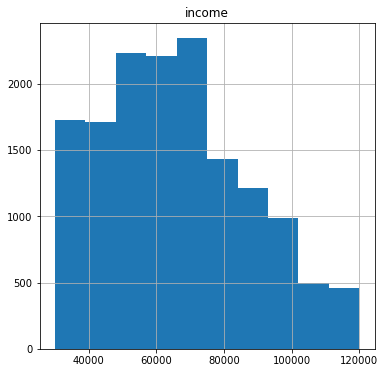

In [18]:
final_df[['person', 'income']].drop_duplicates().hist(figsize=(6,6))

array([[<AxesSubplot:title={'center':'age'}>]], dtype=object)

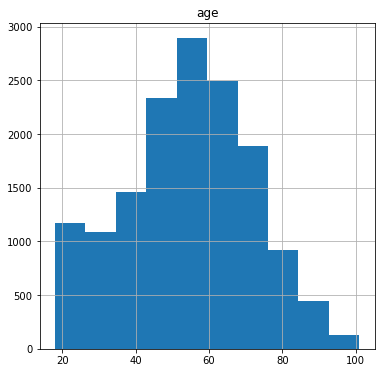

In [19]:
final_df[['person', 'age']].drop_duplicates().hist(figsize=(6,6))

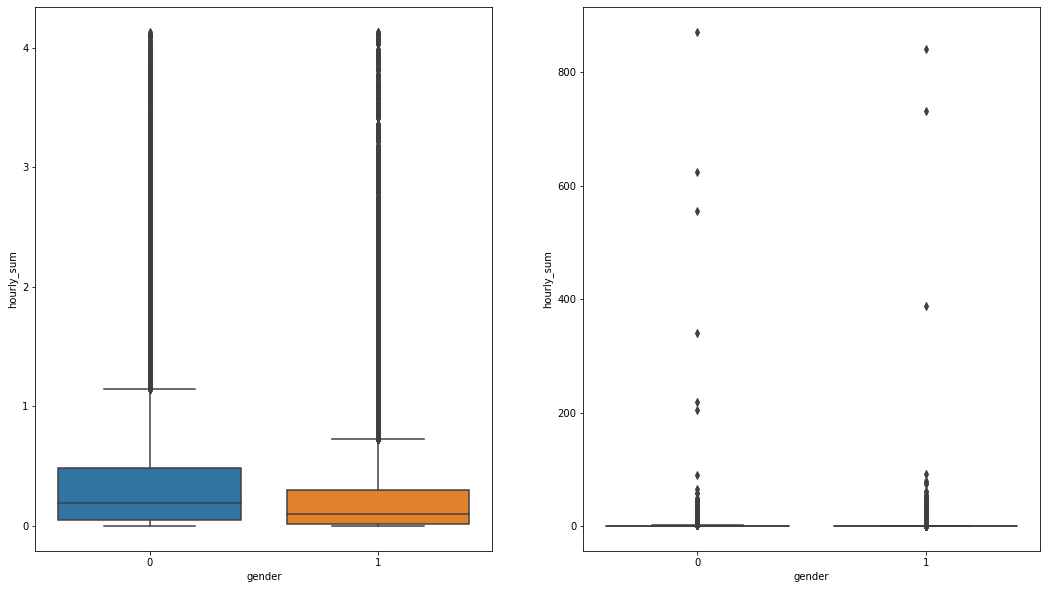

In [20]:
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='gender', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='gender', y='hourly_sum', ax = ax[1])
plt.show();

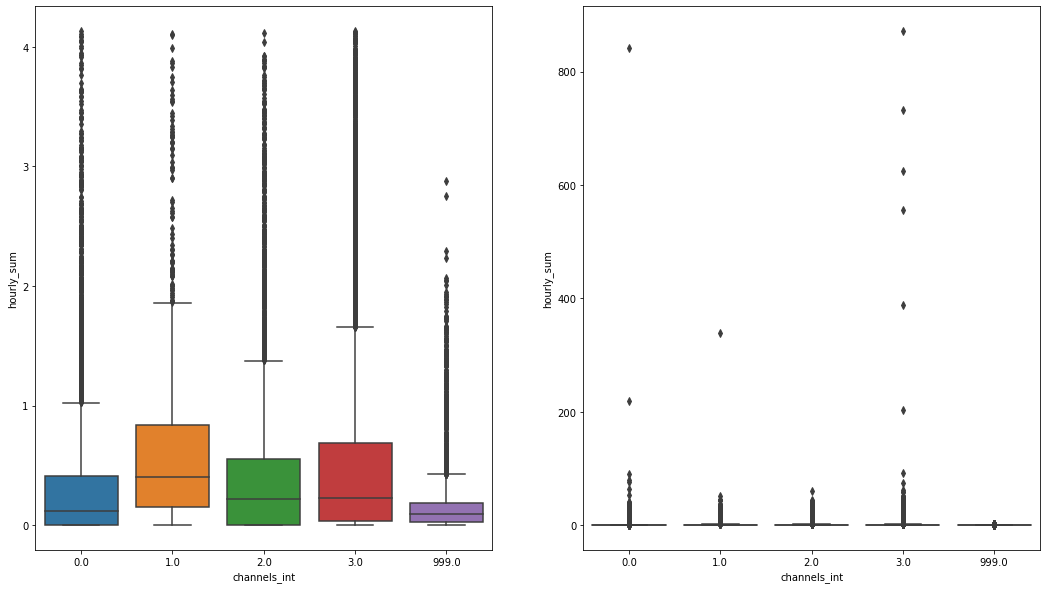

In [21]:
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='channels_int', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='channels_int', y='hourly_sum', ax = ax[1])
plt.show();

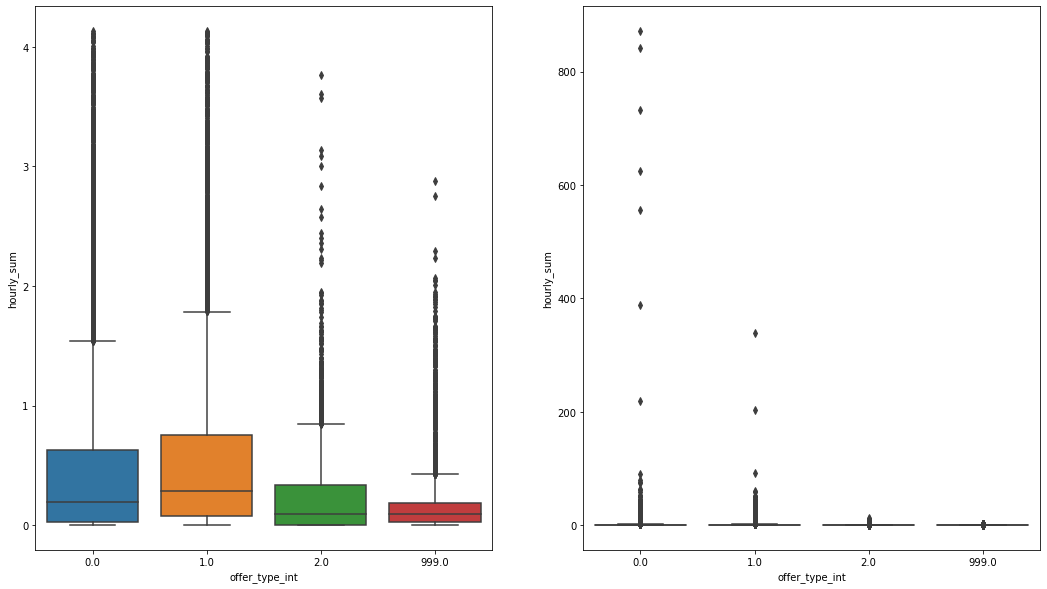

In [22]:
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='offer_type_int', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='offer_type_int', y='hourly_sum', ax = ax[1])
plt.show();

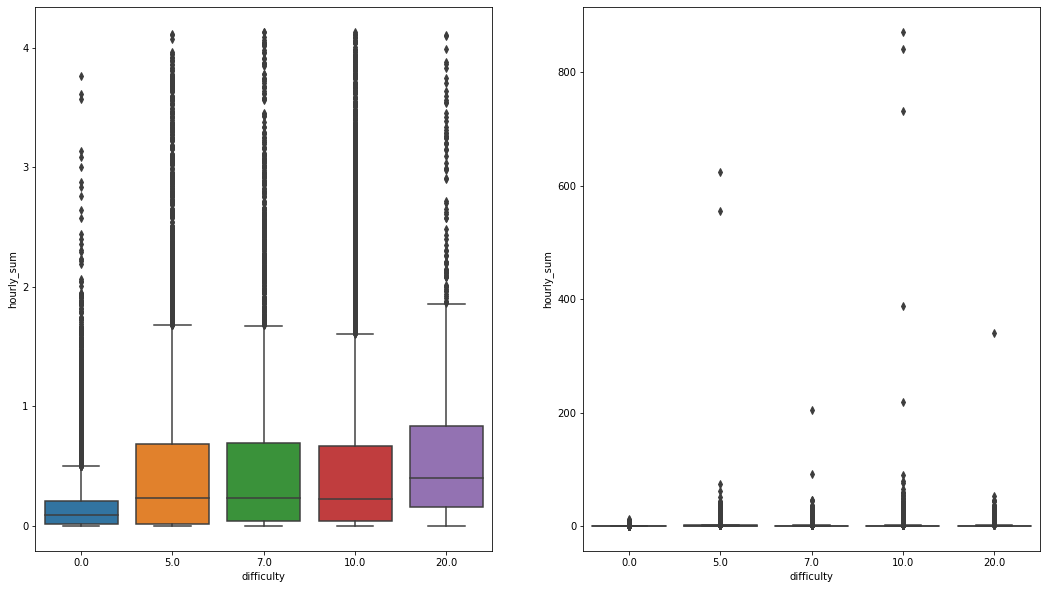

In [23]:
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='difficulty', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='difficulty', y='hourly_sum', ax = ax[1])
plt.show();

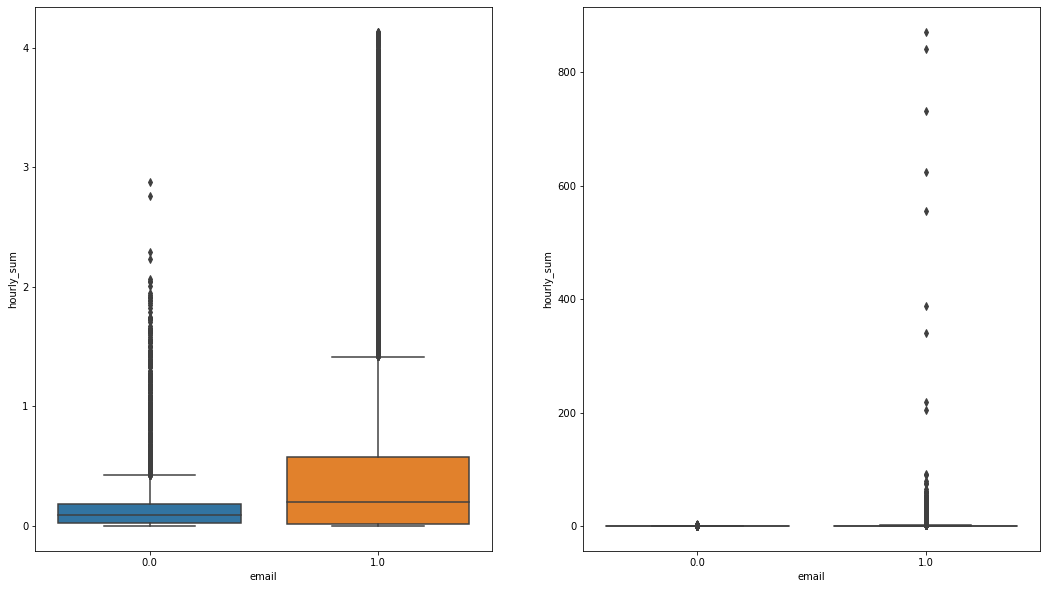

In [24]:
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='email', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='email', y='hourly_sum', ax = ax[1])
plt.show();

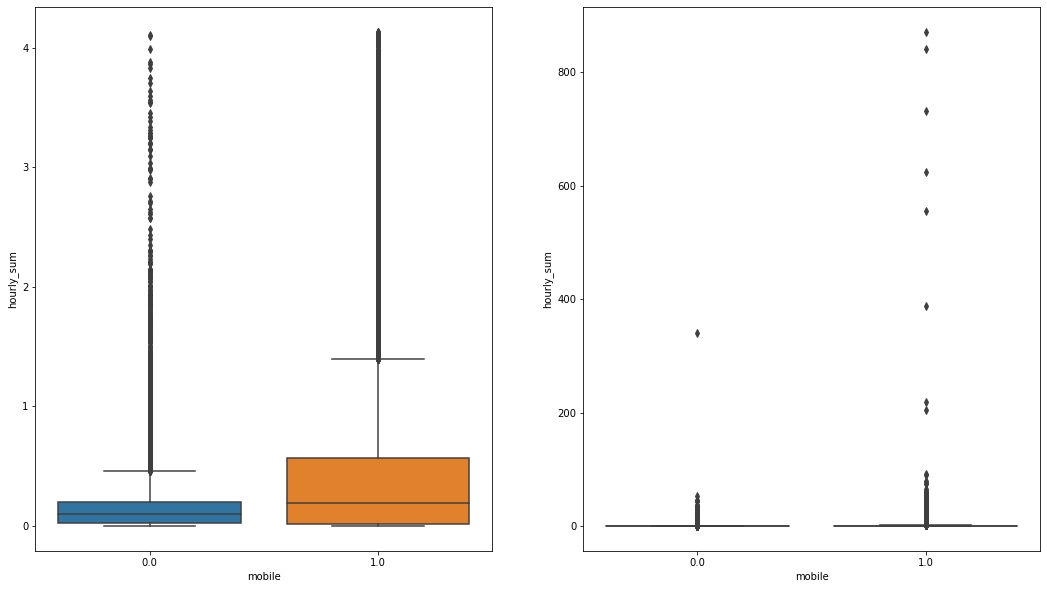

In [25]:
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='mobile', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='mobile', y='hourly_sum', ax = ax[1])
plt.show();

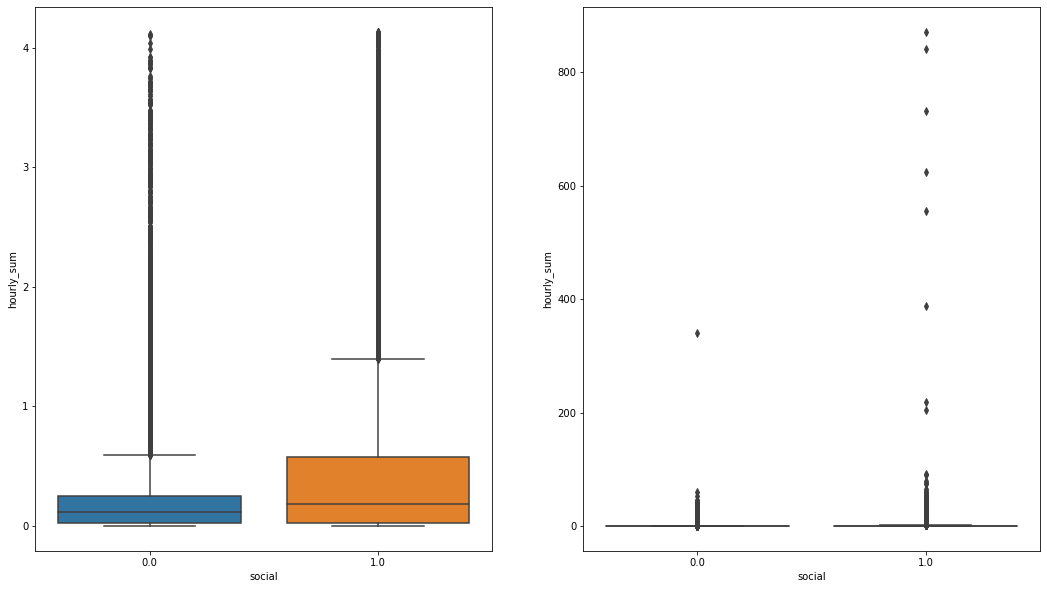

In [26]:
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='social', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='social', y='hourly_sum', ax = ax[1])
plt.show();

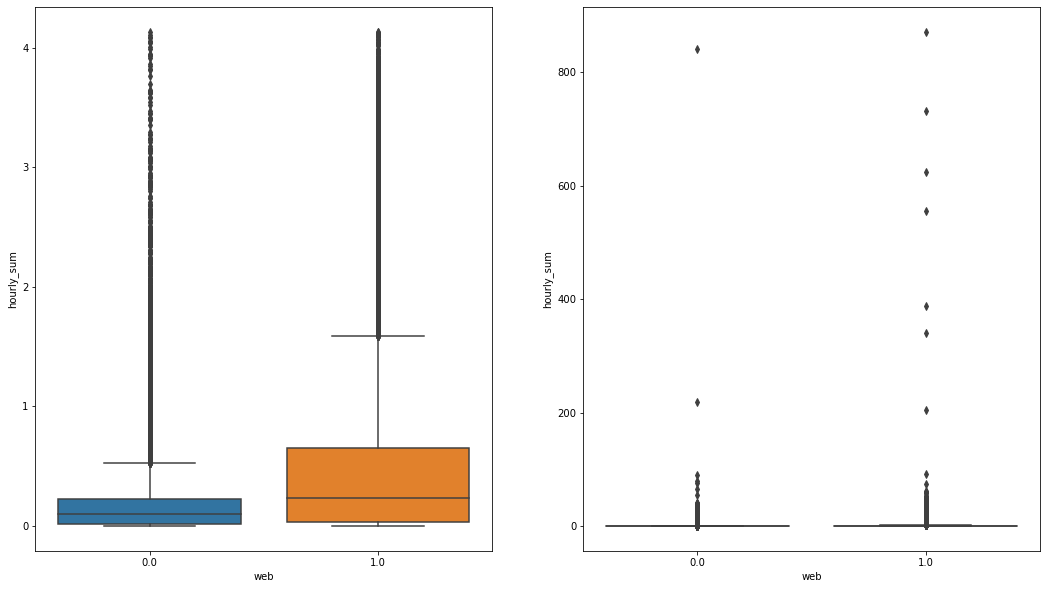

In [27]:
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='web', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='web', y='hourly_sum', ax = ax[1])
plt.show();

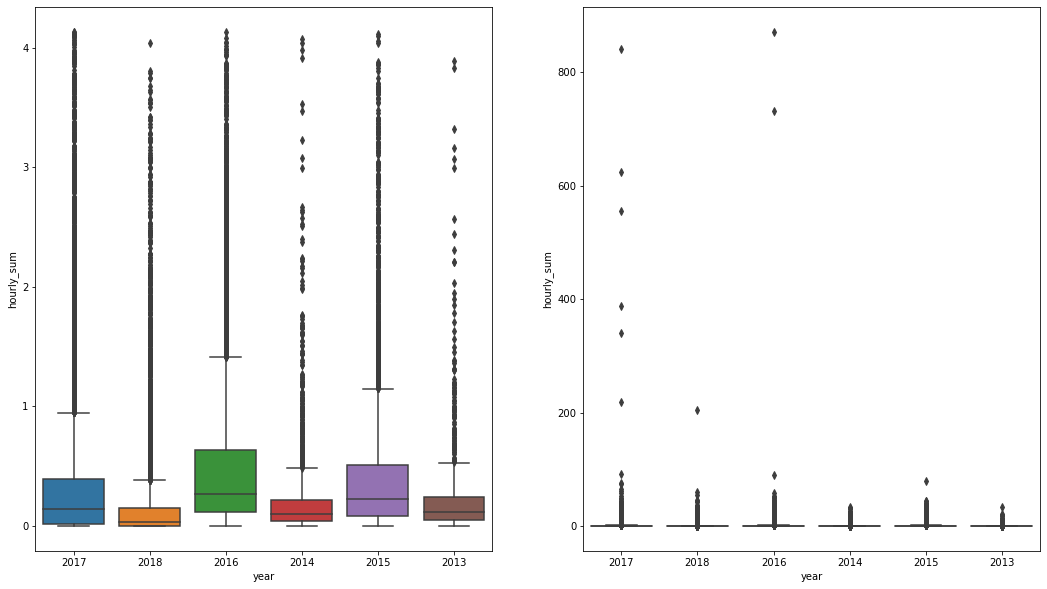

In [28]:
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='year', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='year', y='hourly_sum', ax = ax[1])
plt.show();

0.01700349694795925


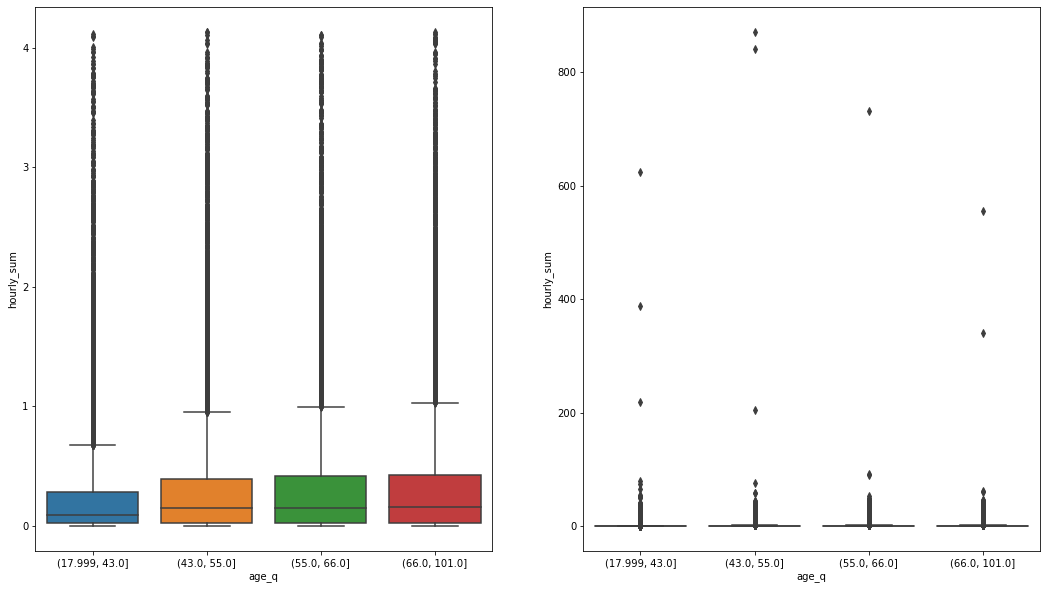

In [29]:
print(final_df['age'].corr(final_df['hourly_sum']))
final_df['age_q'] = pd.qcut(final_df['age'], 4)
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='age_q', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='age_q', y='hourly_sum', ax = ax[1])
plt.show();
del final_df['age_q']

0.01700349694795925


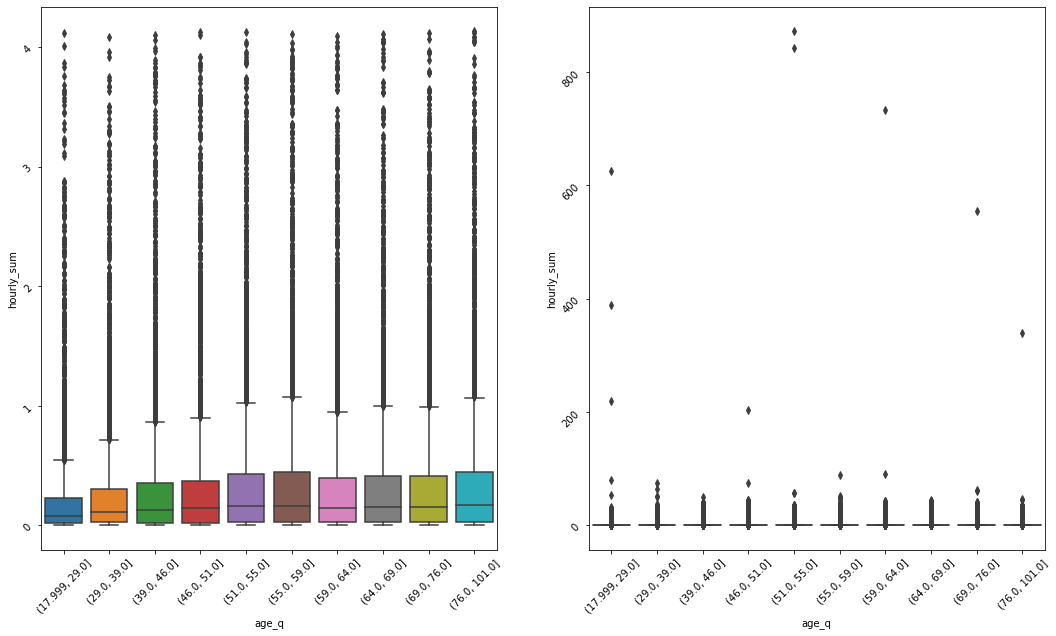

In [30]:
print(final_df['age'].corr(final_df['hourly_sum']))
final_df['age_q'] = pd.qcut(final_df['age'], 10)
fig, ax = plt.subplots(1,2,figsize = (18, 10))
ax[0].tick_params(labelrotation=45)
ax[1].tick_params(labelrotation=45)
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='age_q', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='age_q', y='hourly_sum', ax = ax[1])
plt.show();
del final_df['age_q']

0.06759088216334183


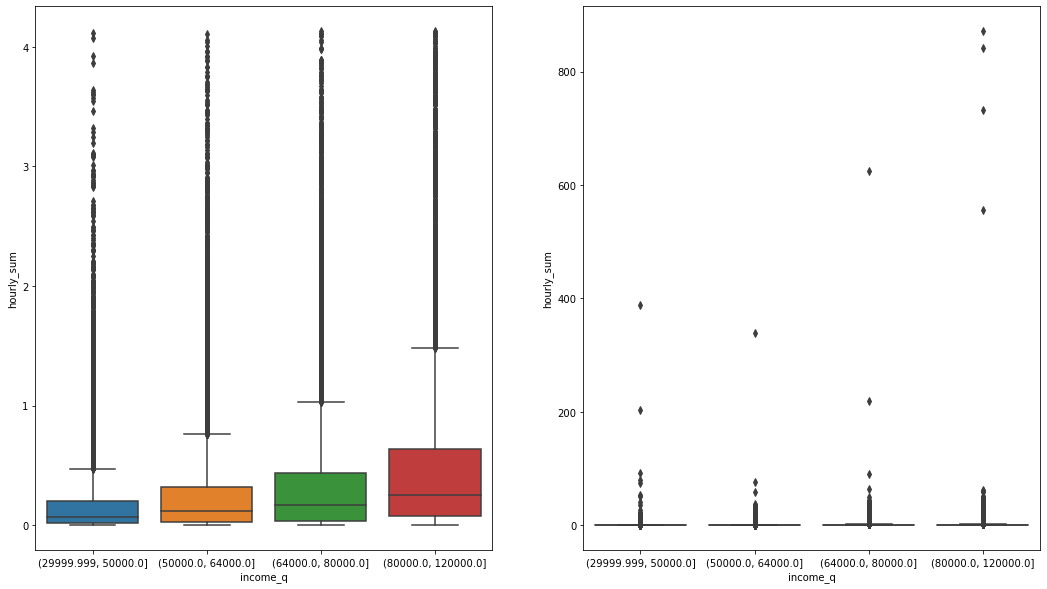

In [31]:
print(final_df['income'].corr(final_df['hourly_sum']))
final_df['income_q'] = pd.qcut(final_df['income'], 4)
fig, ax = plt.subplots(1,2,figsize = (18, 10))
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='income_q', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='income_q', y='hourly_sum', ax = ax[1])
plt.show();
del final_df['income_q']

0.06759088216334183


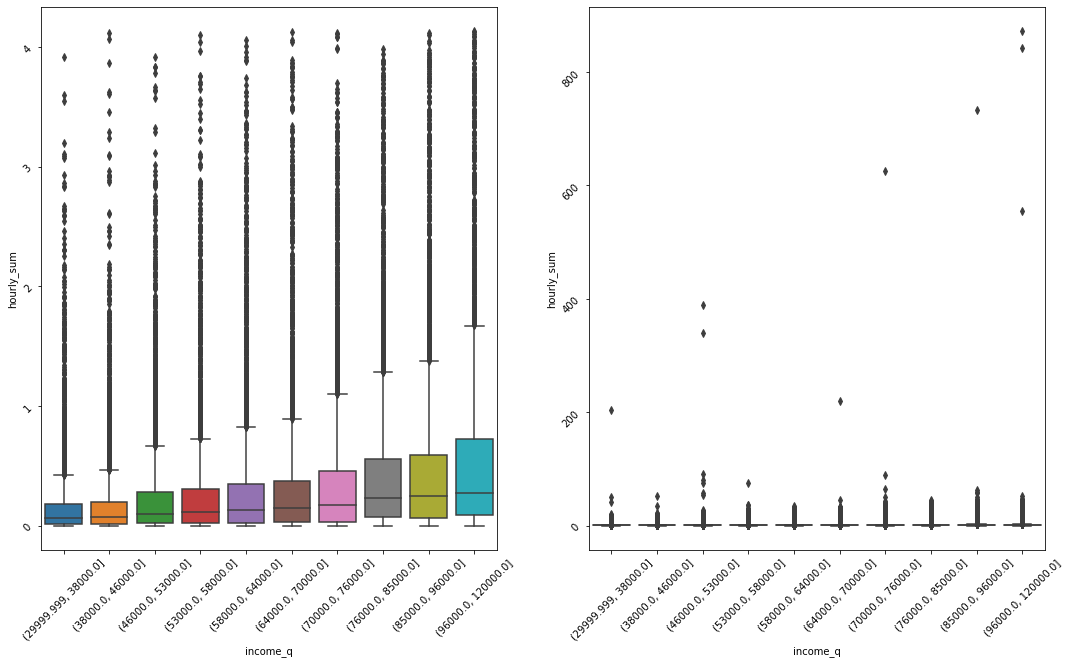

In [32]:
print(final_df['income'].corr(final_df['hourly_sum']))
final_df['income_q'] = pd.qcut(final_df['income'], 10)
fig, ax = plt.subplots(1,2,figsize = (18, 10))
ax[0].tick_params(labelrotation=45)
ax[1].tick_params(labelrotation=45)
sns.boxplot(data=final_df[final_df['hourly_sum'] <= final_df['hourly_sum'].quantile(0.95)], 
            x='income_q', y='hourly_sum', ax = ax[0])
sns.boxplot(data=final_df, x='income_q', y='hourly_sum', ax = ax[1])
plt.show();
del final_df['income_q']